In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


In [8]:
["#0077b6",
"#b53e12",
"#091eb5",
"#b59012",
"#09b594"]

['#0077b6', '#b53e12', '#091eb5', '#b59012', '#09b594']

In [2]:
# Load data
experiment = "KP_KL_Imaging"

# Load Counts
LC_counts = pd.read_csv(f"../data/Lindsay/{experiment}/{experiment}_LC_counts.csv")

# Iterate over each image on the experiment and get the micronuclei ratio
# Initialize a dataframe to store the results
name_mnratio = []
for i in Path(f"../data/Lindsay/{experiment}/predictions/stardist_123456").iterdir():
    if str(i).endswith("_summary.csv"):
        df = pd.read_csv(i, index_col=0)
        print(i.name.split("_")[0])
        name_mnratio.append([i.name.split("_")[0], df.loc["micronuclei_ratio"].values[0]])

# Convert nmbratio to dataframe
df_mnratio = pd.DataFrame(name_mnratio, columns=["file", "micronuclei_ratio"]).sort_values(by="file")

s04
s08
s01
s02
s07
s09
s10
s05
s06
s03


In [3]:
df_mnratio

,file,micronuclei_ratio
2,s01,0.151246
3,s02,0.153896
9,s03,0.163597
0,s04,0.179726
7,s05,0.173136
8,s06,0.089375
4,s07,0.091524
1,s08,0.091369
5,s09,0.090417
6,s10,0.094533


In [4]:
LC_counts

,experiment,cell_line,file,median,min,max
0,KP_KL_imaging,KL,s01,0.18,0.1,0.30
1,KP_KL_imaging,KL,s02,0.18,0.1,0.30
2,KP_KL_imaging,KL,s03,0.18,0.1,0.30
3,KP_KL_imaging,KL,s04,0.18,0.1,0.30
4,KP_KL_imaging,KL,s05,0.18,0.1,0.30
5,KP_KL_imaging,KP,s06,0.06,0.0,0.15
6,KP_KL_imaging,KP,s07,0.06,0.0,0.15
7,KP_KL_imaging,KP,s08,0.06,0.0,0.15
8,KP_KL_imaging,KP,s09,0.06,0.0,0.15
9,KP_KL_imaging,KP,s10,0.06,0.0,0.15


In [5]:
# Merge the two dataframes
predictions_and_counts = pd.merge(LC_counts, df_mnratio, on="file")
predictions_and_counts

,experiment,cell_line,file,median,min,max,micronuclei_ratio
0,KP_KL_imaging,KL,s01,0.18,0.1,0.30,0.151246
1,KP_KL_imaging,KL,s02,0.18,0.1,0.30,0.153896
2,KP_KL_imaging,KL,s03,0.18,0.1,0.30,0.163597
3,KP_KL_imaging,KL,s04,0.18,0.1,0.30,0.179726
4,KP_KL_imaging,KL,s05,0.18,0.1,0.30,0.173136
5,KP_KL_imaging,KP,s06,0.06,0.0,0.15,0.089375
6,KP_KL_imaging,KP,s07,0.06,0.0,0.15,0.091524
7,KP_KL_imaging,KP,s08,0.06,0.0,0.15,0.091369
8,KP_KL_imaging,KP,s09,0.06,0.0,0.15,0.090417
9,KP_KL_imaging,KP,s10,0.06,0.0,0.15,0.094533


In [6]:
# Add the mean of the micronuclei ratio to the dataframe
predictions_and_counts["micronuclei_ratio_mean"] = predictions_and_counts.groupby("cell_line")["micronuclei_ratio"].transform("mean")
predictions_and_counts

,experiment,cell_line,file,median,min,max,micronuclei_ratio,micronuclei_ratio_mean
0,KP_KL_imaging,KL,s01,0.18,0.1,0.30,0.151246,0.164320
1,KP_KL_imaging,KL,s02,0.18,0.1,0.30,0.153896,0.164320
2,KP_KL_imaging,KL,s03,0.18,0.1,0.30,0.163597,0.164320
3,KP_KL_imaging,KL,s04,0.18,0.1,0.30,0.179726,0.164320
4,KP_KL_imaging,KL,s05,0.18,0.1,0.30,0.173136,0.164320
5,KP_KL_imaging,KP,s06,0.06,0.0,0.15,0.089375,0.091444
6,KP_KL_imaging,KP,s07,0.06,0.0,0.15,0.091524,0.091444
7,KP_KL_imaging,KP,s08,0.06,0.0,0.15,0.091369,0.091444
8,KP_KL_imaging,KP,s09,0.06,0.0,0.15,0.090417,0.091444
9,KP_KL_imaging,KP,s10,0.06,0.0,0.15,0.094533,0.091444


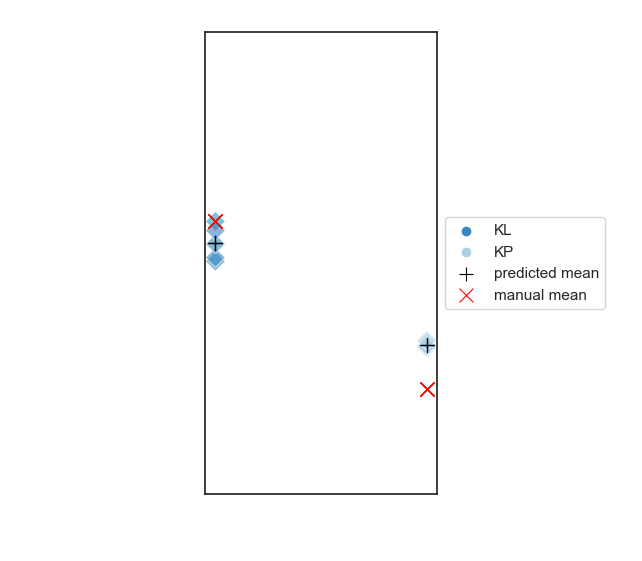

In [7]:
sns.set(rc={'ytick.labelcolor':'white','xtick.labelcolor':'white', 'text.color':'white'})
sns.set_style("white")

fig, ax = plt.subplots(1, 1, figsize=(3,6))
sns.scatterplot(data=predictions_and_counts, x="cell_line", y="micronuclei_ratio", hue="cell_line", palette="Blues_r", marker="D", alpha=0.6,  s=100, ax=ax)
sns.scatterplot(data=predictions_and_counts, x="cell_line", y="micronuclei_ratio_mean", color="black", label="predicted mean", marker="+", s=100, ax=ax)
sns.scatterplot(data=predictions_and_counts, x="cell_line", y="median", color="red", marker="x",label="manual mean", s=100, ax=ax)
sns.scatterplot(data=predictions_and_counts, x="cell_line", y="min", color="white", marker="_", s=100, ax=ax)
sns.scatterplot(data=predictions_and_counts, x="cell_line", y="max", color="white", marker="_", s=100, ax=ax)

ax.set_title(f"Predicted micronuclei ratio compared to manual counts {experiment}", fontsize=14, color="white")
ax.set_xlabel("Cell Line",fontsize=14, color="white")
ax.set_ylabel("MN/Cell",fontsize=14, color="white")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.tick_params(axis="x", labelrotation= 90)
fig.savefig(f"../data/Lindsay/{experiment}/figures/micronuclei_ratio_comparison_cell_lines.pdf", bbox_inches="tight",dpi=300, transparent=True)
fig.savefig(f"../data/Lindsay/{experiment}/figures/micronuclei_ratio_comparison_cell_lines.png", bbox_inches="tight",dpi=300, transparent=True)